In [8]:
import pandas as pd

df = pd.read_csv('../data/cs-training.csv', index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
print(df.shape)
df.info()

(150000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dty

In [10]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [11]:
df.describe()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


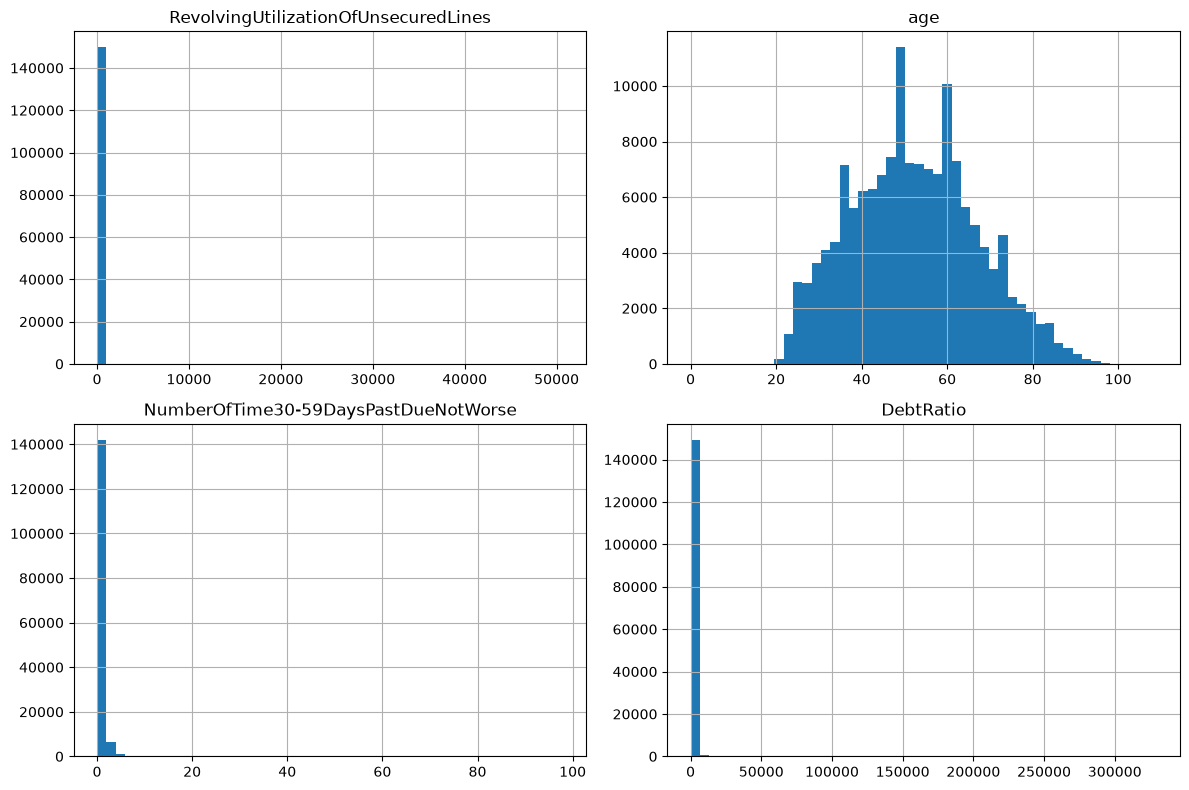

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['RevolvingUtilizationOfUnsecuredLines'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('RevolvingUtilizationOfUnsecuredLines')

df['age'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('age')

df['NumberOfTime30-59DaysPastDueNotWorse'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('NumberOfTime30-59DaysPastDueNotWorse')

df['DebtRatio'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('DebtRatio')

plt.tight_layout()
plt.show()

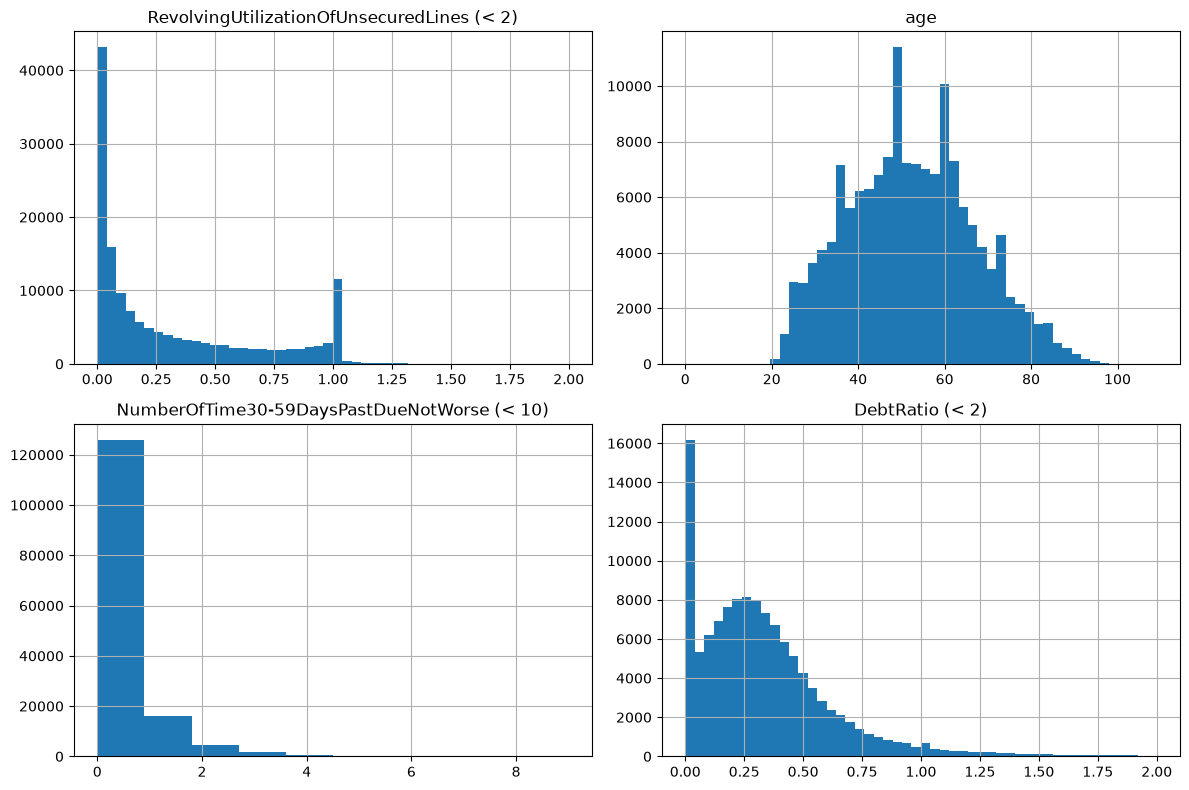

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df[df['RevolvingUtilizationOfUnsecuredLines'] < 2]['RevolvingUtilizationOfUnsecuredLines'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('RevolvingUtilizationOfUnsecuredLines (< 2)')

df['age'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('age')

df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 10]['NumberOfTime30-59DaysPastDueNotWorse'].hist(bins=10, ax=axes[1,0])
axes[1,0].set_title('NumberOfTime30-59DaysPastDueNotWorse (< 10)')

df[df['DebtRatio'] < 2]['DebtRatio'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('DebtRatio (< 2)')

plt.tight_layout()
plt.show()

In [16]:
print("Age = 0 rows:", (df['age'] == 0).sum())
print("Past-due 96/98 rows:", ((df['NumberOfTime30-59DaysPastDueNotWorse'] >= 96) | 
                                 (df['NumberOfTimes90DaysLate'] >= 96) | 
                                 (df['NumberOfTime60-89DaysPastDueNotWorse'] >= 96)).sum())
print("RevolvingUtilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print("DebtRatio > 2:", (df['DebtRatio'] > 2).sum())

Age = 0 rows: 1
Past-due 96/98 rows: 269
RevolvingUtilization > 2: 371
DebtRatio > 2: 31045


In [17]:
df[df['DebtRatio'] > 2][['DebtRatio', 'MonthlyIncome']].describe()

,DebtRatio,MonthlyIncome
count,31045.000000,3301.000000
mean,1704.315902,815.863375
std,4214.550941,2090.107580
min,2.000400,0.000000
25%,181.000000,0.000000
50%,1197.000000,1.000000
75%,2395.000000,770.000000
max,329664.000000,33333.000000


In [18]:
print("Rows with DebtRatio > 2 AND MonthlyIncome missing:", 
      df[(df['DebtRatio'] > 2) & (df['MonthlyIncome'].isna())].shape[0])

Rows with DebtRatio > 2 AND MonthlyIncome missing: 27744


In [19]:
df = df[df['age'] > 0].copy()

df['MonthlyIncome_missing'] = df['MonthlyIncome'].isna().astype(int)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

print("Age=0 rows remaining:", (df['age'] == 0).sum())
print("MonthlyIncome missing after imputation:", df['MonthlyIncome'].isna().sum())
print("Median income used:", median_income)

Age=0 rows remaining: 0
MonthlyIncome missing after imputation: 0
Median income used: 5400.0


In [20]:
print("DebtRatio > 2 rows now:", (df['DebtRatio'] > 2).sum())
df[df['DebtRatio'] > 2][['DebtRatio', 'MonthlyIncome']].describe()

DebtRatio > 2 rows now: 31045


,DebtRatio,MonthlyIncome
count,31045.000000,31045.000000
mean,1704.315902,4912.570945
std,4214.550941,1568.852658
min,2.000400,0.000000
25%,181.000000,5400.000000
50%,1197.000000,5400.000000
75%,2395.000000,5400.000000
max,329664.000000,33333.000000


In [21]:
df['DebtRatio_capped'] = (df['DebtRatio'] > 2).astype(int)
df['DebtRatio'] = df['DebtRatio'].clip(upper=2)

print("DebtRatio > 2 after capping:", (df['DebtRatio'] > 2).sum())
print(df['DebtRatio'].describe())

DebtRatio > 2 after capping: 0
count    149999.000000
mean          0.682430
std           0.722900
min           0.000000
25%           0.175074
50%           0.366503
75%           0.868257
max           2.000000
Name: DebtRatio, dtype: float64


In [22]:
sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
                  'NumberOfTimes90DaysLate', 
                  'NumberOfTime60-89DaysPastDueNotWorse']

df['HasSentinelPastDue'] = (df[sentinel_cols] >= 96).any(axis=1).astype(int)
for col in sentinel_cols:
    df[col] = df[col].clip(upper=18)

df['RevolvingUtilization_capped'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 2).astype(int)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

print("Sentinel flag count:", df['HasSentinelPastDue'].sum())
print("RevolvingUtilization capped count:", df['RevolvingUtilization_capped'].sum())

Sentinel flag count: 269
RevolvingUtilization capped count: 371


In [23]:
print(df['NumberOfDependents'].value_counts(dropna=False).sort_index())

NumberOfDependents
0.0     86902
1.0     26316
2.0     19521
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
NaN      3924
Name: count, dtype: int64


In [36]:
df['NumberOfDependents_missing'] = df['NumberOfDependents'].isna().astype(int)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

print("NumberOfDependents missing after imputation:", df['NumberOfDependents'].isna().sum())
print(df['NumberOfDependents'].value_counts().sort_index())

NumberOfDependents missing after imputation: 0
NumberOfDependents
0.0     90826
1.0     26316
2.0     19521
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
Name: count, dtype: int64


In [25]:
df.to_csv('../data/cs-training-cleaned.csv', index=True)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (149999, 16)


In [26]:
# Total past-due events across all three categories
df['TotalPastDueEvents'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                              df['NumberOfTime60-89DaysPastDueNotWorse'] + 
                              df['NumberOfTimes90DaysLate'])

# Income per dependent (avoid divide by zero by adding 1)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Binary flag for having any real estate loan
df['HasRealEstateLoan'] = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)

# Age buckets
df['AgeBucket'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])

print(df[['TotalPastDueEvents', 'IncomePerDependent', 'HasRealEstateLoan', 'AgeBucket']].head())

   TotalPastDueEvents  IncomePerDependent  HasRealEstateLoan AgeBucket
1                   2              3040.0                  1     30-45
2                   0              1300.0                  0     30-45
3                   2              3042.0                  0     30-45
4                   0              3300.0                  0       <30
5                   1             63588.0                  1     45-60


In [27]:
for col in ['TotalPastDueEvents', 'HasRealEstateLoan']:
    print(f"\n{col} vs SeriousDlqin2yrs:")
    print(df.groupby(col)['SeriousDlqin2yrs'].mean())

print("\nAgeBucket vs SeriousDlqin2yrs:")
print(df.groupby('AgeBucket', observed=True)['SeriousDlqin2yrs'].mean())



TotalPastDueEvents vs SeriousDlqin2yrs:
TotalPastDueEvents
0     0.027283
1     0.122144
2     0.240828
3     0.349515
4     0.426332
5     0.508511
6     0.584459
7     0.605263
8     0.598985
9     0.672000
10    0.684932
11    0.679245
12    0.555556
13    0.789474
14    0.692308
15    0.888889
16    0.250000
17    0.750000
18    1.000000
19    0.500000
54    0.546468
Name: SeriousDlqin2yrs, dtype: float64

HasRealEstateLoan vs SeriousDlqin2yrs:
HasRealEstateLoan
0    0.083149
1    0.057072
Name: SeriousDlqin2yrs, dtype: float64

AgeBucket vs SeriousDlqin2yrs:
AgeBucket
<30      0.115646
30-45    0.093102
45-60    0.068183
60+      0.029947
Name: SeriousDlqin2yrs, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
feature_cols = [col for col in df.columns if col not in ['SeriousDlqin2yrs']]
X = df[feature_cols]
y = df['SeriousDlqin2yrs']

# One-hot encode AgeBucket since models need numbers, not category labels
X = pd.get_dummies(X, columns=['AgeBucket'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))

Train shape: (119999, 21)
Test shape: (30000, 21)
Train target balance:
 SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64
Test target balance:
 SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# class_weight='balanced' automatically adjusts for our 93/7 imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8578440307518399

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000



/Users/zubair/Documents/Credit-Risk-Model/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8632351341685081

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.81      0.85     30000



In [33]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class balancing for XGBoost specifically
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.8685770749051643

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000



In [34]:
import pandas as pd

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

TotalPastDueEvents                      0.711718
RevolvingUtilizationOfUnsecuredLines    0.078611
NumberOfTimes90DaysLate                 0.032298
NumberRealEstateLoansOrLines            0.026713
MonthlyIncome_missing                   0.019477
NumberOfTime30-59DaysPastDueNotWorse    0.017111
age                                     0.014134
NumberOfTime60-89DaysPastDueNotWorse    0.013864
DebtRatio                               0.012805
NumberOfOpenCreditLinesAndLoans         0.012411
dtype: float32

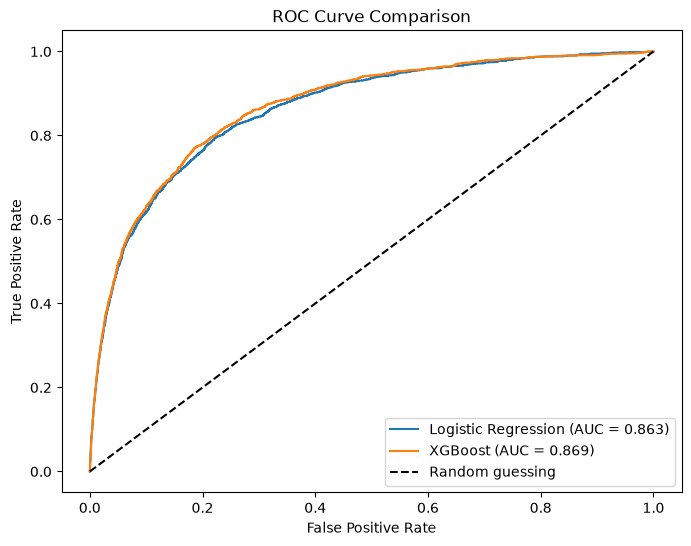

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get false positive rate / true positive rate for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

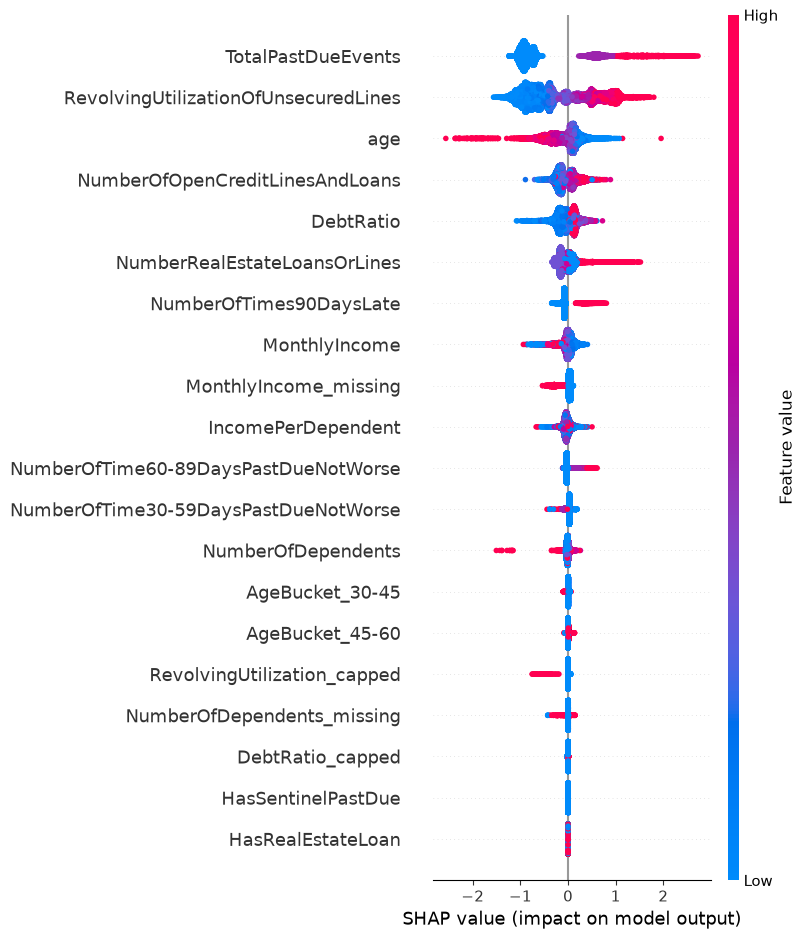

In [37]:
import shap

# Create explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot - shows overall feature impact across all predictions
shap.summary_plot(shap_values, X_test)